In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import json
import os

df = pd.read_csv('../data/tarkwa_nasa_monthly.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# UNIVARIATE: only rainfall-derived features (no climate variables)
df['month_num'] = df['date'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
df['rainfall_lag1'] = df['rainfall_mm'].shift(1)
df['rainfall_lag2'] = df['rainfall_mm'].shift(2)
df['rainfall_roll3'] = df['rainfall_mm'].shift(1).rolling(3).mean()

df = df.dropna().reset_index(drop=True)

UNI_COLS = ['month_sin', 'month_cos', 'rainfall_lag1', 'rainfall_lag2', 'rainfall_roll3']

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(df[['date', 'rainfall_mm'] + UNI_COLS].head())

Dataset shape: (435, 17)
Date range: 1990-04-01 00:00:00 to 2026-06-01 00:00:00
        date  rainfall_mm     month_sin  month_cos  rainfall_lag1  \
0 1990-04-01       251.53  8.660254e-01  -0.500000          70.49   
1 1990-05-01       187.32  5.000000e-01  -0.866025         251.53   
2 1990-06-01       199.58  1.224647e-16  -1.000000         187.32   
3 1990-07-01       104.21 -5.000000e-01  -0.866025         199.58   
4 1990-08-01        33.37 -8.660254e-01  -0.500000         104.21   

   rainfall_lag2  rainfall_roll3  
0          98.45       68.620000  
1          70.49      140.156667  
2         251.53      169.780000  
3         187.32      212.810000  
4         199.58      163.703333  


In [2]:
split_date = '2019-01-01'

train_df = df[df['date'] < split_date].reset_index(drop=True)
test_df  = df[df['date'] >= split_date].reset_index(drop=True)

X_train = train_df[UNI_COLS].values
X_test  = test_df[UNI_COLS].values
y_train = train_df['rainfall_mm'].values
y_test  = test_df['rainfall_mm'].values

train_dates = train_df['date']
test_dates  = test_df['date']

print(f"Training months: {len(y_train)} (Jan 1990 – Dec 2018)")
print(f"Test months:     {len(y_test)}  (Jan 2019 – Jun 2026)")
print(f"Number of predictors: {X_train.shape[1]}")

Training months: 345 (Jan 1990 – Dec 2018)
Test months:     90  (Jan 2019 – Jun 2026)
Number of predictors: 5


In [3]:
print("Fitting XGBoost (univariate: seasonality + rainfall lags only)...")

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
xgb_model.fit(X_train, y_train)

importances = pd.DataFrame({
    'feature': UNI_COLS,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print(importances)

Fitting XGBoost (univariate: seasonality + rainfall lags only)...
          feature  importance
1       month_cos    0.556273
0       month_sin    0.192390
2   rainfall_lag1    0.100462
3   rainfall_lag2    0.076264
4  rainfall_roll3    0.074611


In [4]:
print("Running walk-forward validation on test set...")

history_X = list(X_train)
history_y = list(y_train)
predictions = []

for i in range(len(y_test)):
    model = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )
    model.fit(np.array(history_X), np.array(history_y))

    yhat = model.predict(X_test[i].reshape(1, -1))[0]
    yhat = max(0, yhat)
    predictions.append(yhat)

    history_X.append(X_test[i])
    history_y.append(y_test[i])
    if (i+1) % 10 == 0:
        print(f"  Completed {i+1}/{len(y_test)} steps")

predictions = np.array(predictions)
print("Walk-forward validation complete.")

Running walk-forward validation on test set...
  Completed 10/90 steps
  Completed 20/90 steps
  Completed 30/90 steps
  Completed 40/90 steps
  Completed 50/90 steps
  Completed 60/90 steps
  Completed 70/90 steps
  Completed 80/90 steps
  Completed 90/90 steps
Walk-forward validation complete.


In [5]:
mae  = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2   = r2_score(y_test, predictions)

mask = y_test > 0
mape = np.mean(np.abs((y_test[mask] - predictions[mask]) / y_test[mask])) * 100

print("=== XGBoost (Univariate) — Test Set Performance ===")
print(f"MAE  : {mae:.2f} mm")
print(f"RMSE : {rmse:.2f} mm")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%  (non-zero months only)")

=== XGBoost (Univariate) — Test Set Performance ===
MAE  : 67.80 mm
RMSE : 92.13 mm
R²   : 0.3914
MAPE : 54.87%  (non-zero months only)


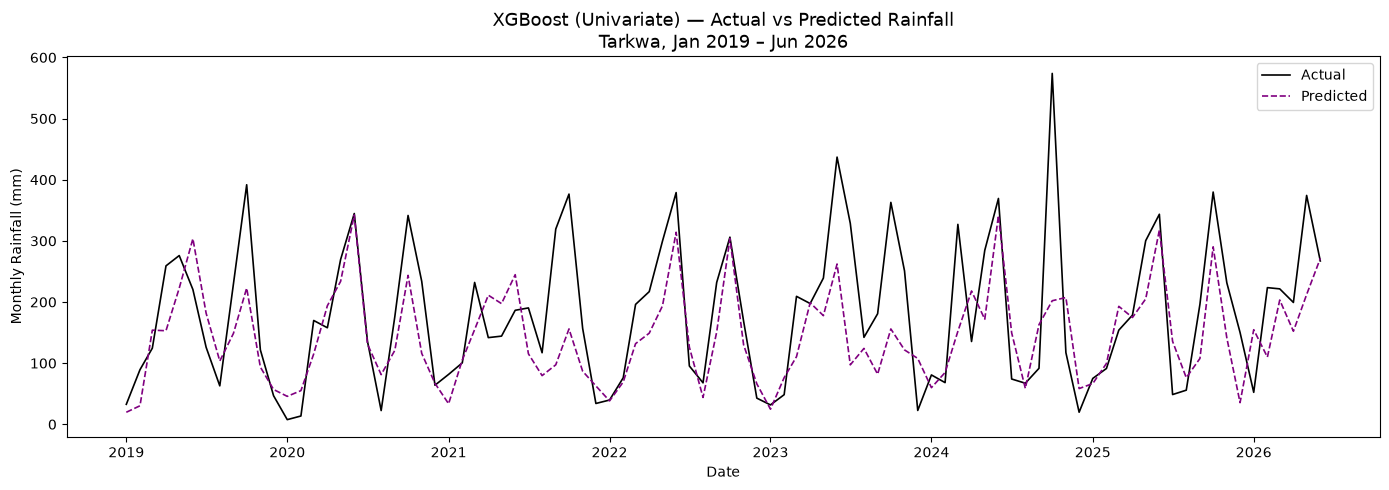

Plot saved.


In [6]:
plt.figure(figsize=(14, 5))
plt.plot(test_dates.values, y_test,       label='Actual',    color='black', linewidth=1.2)
plt.plot(test_dates.values, predictions,  label='Predicted', color='purple',
         linewidth=1.2, linestyle='--')
plt.title('XGBoost (Univariate) — Actual vs Predicted Rainfall\nTarkwa, Jan 2019 – Jun 2026',
          fontsize=13)
plt.xlabel('Date')
plt.ylabel('Monthly Rainfall (mm)')
plt.legend()
plt.tight_layout()
os.makedirs('../models', exist_ok=True)
plt.savefig('../models/xgb_uni_actual_vs_predicted.png', dpi=150)
plt.show()
print("Plot saved.")

In [7]:
joblib.dump({
    'model_fit': xgb_model,
    'predictors': UNI_COLS,
    'model_type': 'XGBoost_univariate',
}, '../models/xgb_uni_model.pkl')

results = {
    'model': 'XGBoost',
    'mode': 'univariate',
    'mae': round(mae, 2),
    'rmse': round(rmse, 2),
    'r2': round(r2, 4),
    'mape': round(mape, 2),
}
with open('../models/xgb_uni_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Model saved to models/xgb_uni_model.pkl")
print("Results saved to models/xgb_uni_results.json")
print(f"\nSummary: XGBoost (univariate)")
print(f"  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}  MAPE={mape:.2f}%")

Model saved to models/xgb_uni_model.pkl
Results saved to models/xgb_uni_results.json

Summary: XGBoost (univariate)
  MAE=67.80  RMSE=92.13  R²=0.3914  MAPE=54.87%
